# **Notebook:1 (Data)**

In [ ]:
!pip install obspy
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

In [ ]:
client = Client("USGS")
catalog=client.get_events(starttime=UTCDateTime("1966-01-01"),endtime=UTCDateTime("2006-01-01"),minmagnitude=1,minlatitude=30,maxlatitude=34,minlongitude=23,maxlongitude=30)
print(catalog)
print("number of events:",len(catalog))

131 Event(s) in Catalog:
2005-11-29T16:55:00.900000Z | +33.860,  +26.140 | 3.4  md | manual
2005-11-26T20:29:07.500000Z | +33.660,  +26.270 | 3.6  md | manual
...
1975-07-25T11:56:04.500000Z | +33.944,  +23.120 | 3.9  mb | manual
1974-03-07T03:50:29.000000Z | +33.917,  +25.542 | 4.3  mb | manual
To see all events call 'print(CatalogObject.__str__(print_all=True))'
number of events: 131


In [ ]:
import pandas as pd
rows=[]
for event in catalog:
 origin=event.origins[0]
 mag=event.magnitudes[0]

 rows.append({"time":origin.time.datetime,"latitude":origin.latitude,"longitude":origin.longitude,"depth_km":origin.depth/1000,"magnitude":mag.mag})
df=pd.DataFrame(rows)
print(df.head(10))

                     time  latitude  longitude  depth_km  magnitude
0 2005-11-29 16:55:00.900    33.860     26.140      12.0        3.4
1 2005-11-26 20:29:07.500    33.660     26.270      11.0        3.6
2 2005-11-24 21:25:07.210    33.991     25.734      27.6        4.4
3 2005-11-24 21:00:19.700    33.900     25.730      25.0        4.4
4 2005-11-16 16:40:35.450    32.857     23.495      10.0        4.5
5 2005-10-28 09:27:22.200    33.890     26.310       6.0        3.8
6 2005-09-03 06:02:38.030    33.963     25.884      40.6        4.3
7 2005-03-29 14:26:33.500    33.310     25.340      36.0        3.7
8 2005-03-19 15:27:19.100    33.840     26.040       5.0        3.6
9 2005-01-02 11:27:17.000    33.950     25.090      19.0        3.5


In [ ]:

df.to_csv("EastCape_catalog.csv", index=False)

print("CSV saved successfully")

CSV saved successfully


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("EastCape_catalog.csv")

df.head()

,time,latitude,longitude,depth_km,magnitude
0,2005-11-29 16:55:00.900,33.860,26.140,12.0,3.4
1,2005-11-26 20:29:07.500,33.660,26.270,11.0,3.6
2,2005-11-24 21:25:07.210,33.991,25.734,27.6,4.4
3,2005-11-24 21:00:19.700,33.900,25.730,25.0,4.4
4,2005-11-16 16:40:35.450,32.857,23.495,10.0,4.5


# **Notebook:2 (Plots)**

**(a)Frequency-Magnitude Histogram**

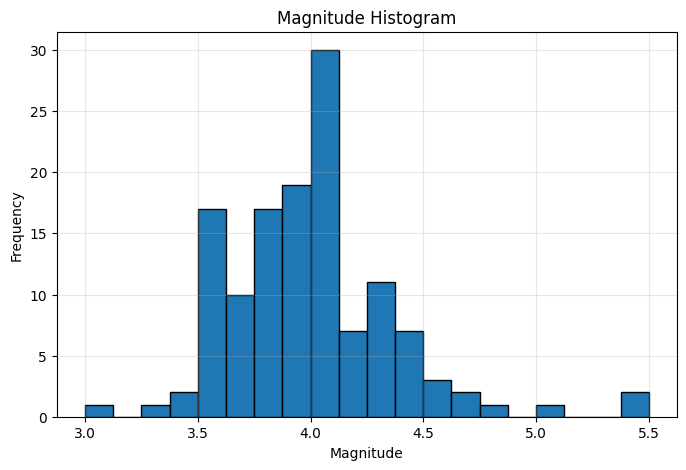

In [ ]:
#Plot linear frequency histogram
mags = df['magnitude']

plt.figure(figsize=(8,5))
plt.hist(mags, bins=20, edgecolor='black')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.title('Magnitude Histogram')
plt.grid(alpha=0.3)
plt.show()

**(b)log frequency Histogram**

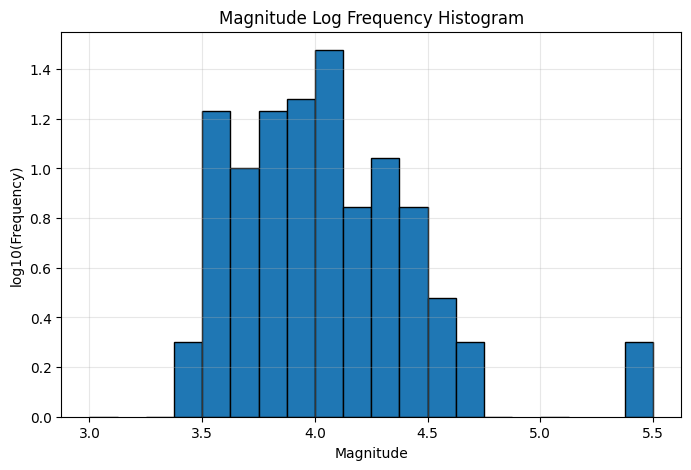

In [ ]:
#plot log frequency curve

# Calculate histogram bins and counts
hist_counts, bin_edges = np.histogram(mags, bins=20)

# Find positive frequencies
positive_counts = hist_counts[hist_counts > 0]

# Take the log10 of the positive frequencies
log_frequencies = np.log10(positive_counts)

# Prepare the magnitude values for plotting (midpoints of bins)
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(8,5))
# Plot only the bins that had positive counts
plt.bar(bin_mids[hist_counts > 0], log_frequencies, width=np.diff(bin_edges)[0], edgecolor='black')
plt.xlabel('Magnitude')
plt.ylabel('log10(Frequency)')
plt.title('Magnitude Log Frequency Histogram')
plt.grid(alpha=0.3)
plt.show()

**(c)Epicentral Plot**

In [ ]:
!pip install cartopy

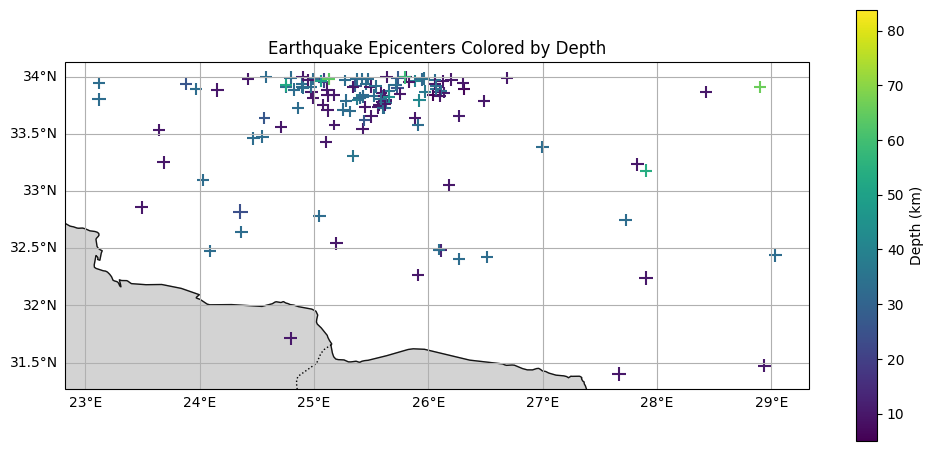

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

df=pd.read_csv(Path("EastCape_catalog.csv"))
fig = plt.figure(figsize=(12,8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and borders
ax.coastlines(alpha=0.9)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, color='lightgrey')

# Plot epicenters colored by depth
sc = ax.scatter(df['longitude'],df['latitude'],marker='+',c=df['depth_km'],cmap='viridis',s=df['magnitude']*20,transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('Depth (km)')

# Gridlines
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

plt.title("Earthquake Epicenters Colored by Depth")
plt.show()


**(d)Vertical Cross-section Plot**

In [ ]:
subset = df[
    (df["depth_km"] >= 0) &
    (df["depth_km"] < 70) ]


In [ ]:
print(subset.shape)
print(subset.head())

(130, 5)
                      time  latitude  longitude  depth_km  magnitude
0  2005-11-29 16:55:00.900    33.860     26.140      12.0        3.4
1  2005-11-26 20:29:07.500    33.660     26.270      11.0        3.6
2  2005-11-24 21:25:07.210    33.991     25.734      27.6        4.4
3  2005-11-24 21:00:19.700    33.900     25.730      25.0        4.4
4  2005-11-16 16:40:35.450    32.857     23.495      10.0        4.5


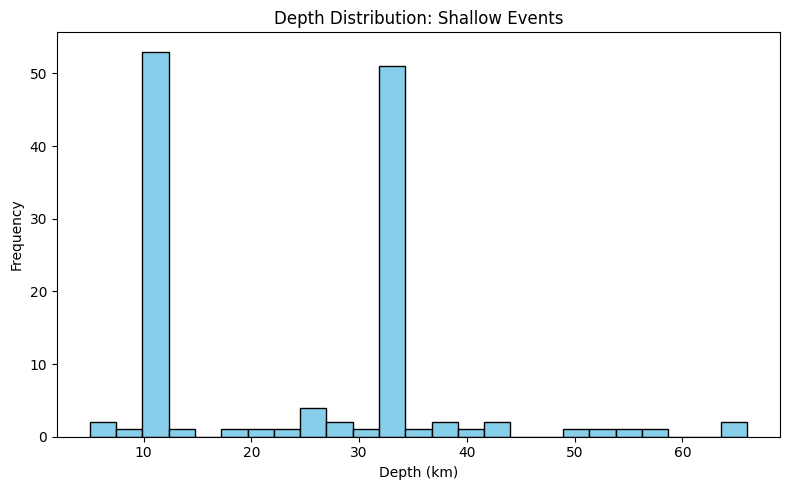

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(subset["depth_km"], bins=25,
         color="skyblue",
         edgecolor="black")

plt.title("Depth Distribution: Shallow Events")
plt.xlabel("Depth (km)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**(e)Interevent Time Plot**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy.stats import expon
df=pd.read_csv(Path("EastCape_catalog.csv"))
df.head()

,time,latitude,longitude,depth_km,magnitude
0,2005-11-29 16:55:00.900,33.860,26.140,12.0,3.4
1,2005-11-26 20:29:07.500,33.660,26.270,11.0,3.6
2,2005-11-24 21:25:07.210,33.991,25.734,27.6,4.4
3,2005-11-24 21:00:19.700,33.900,25.730,25.0,4.4
4,2005-11-16 16:40:35.450,32.857,23.495,10.0,4.5


Estimated lambda: 0.0004673349487665224
Mean inter-event time: 2139.792888675214 hours


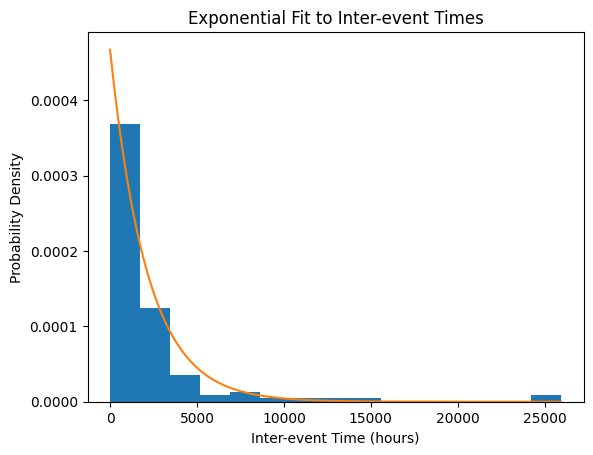

In [ ]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')
inter_event = df['time'].diff().dt.total_seconds()
inter_event = inter_event.dropna()
inter_event_hours = inter_event / 3600
loc, scale = expon.fit(inter_event_hours, floc=0)
lambda_est = 1 / scale

print("Estimated lambda:", lambda_est)
print("Mean inter-event time:", scale, "hours")

plt.hist(inter_event_hours, bins=15, density=True)

x = np.linspace(0, inter_event_hours.max(), 200)
pdf = expon.pdf(x, loc=loc, scale=scale)

plt.plot(x, pdf)

plt.xlabel("Inter-event Time (hours)")
plt.ylabel("Probability Density")
plt.title("Exponential Fit to Inter-event Times")

plt.show()


**(f)Histogram Plot Of Depths Of Events**

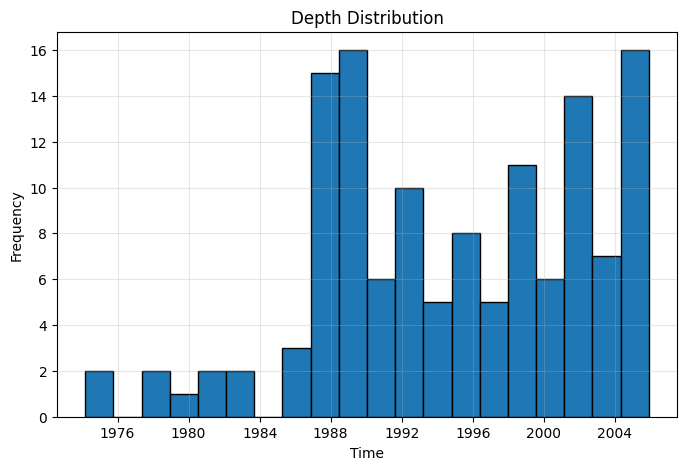

In [ ]:
df['time'] = pd.to_datetime(df['time'])

plt.figure(figsize=(8,5))
plt.hist(df['time'], bins=20, edgecolor='black')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.title('Depth Distribution')
plt.grid(alpha=0.3)
plt.show()

**(g)Scatter Plot**

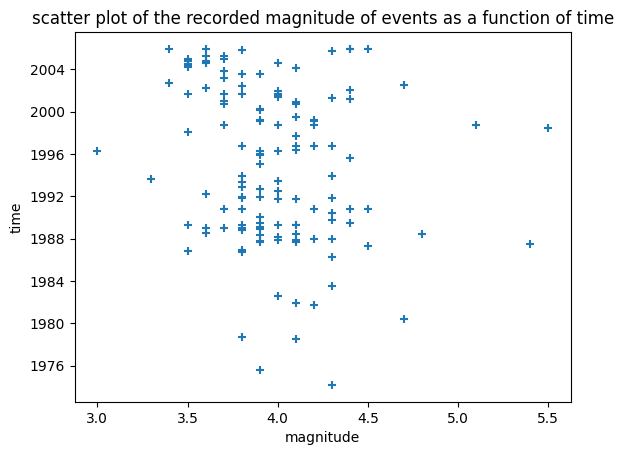

In [ ]:
# Code to make a scatter plot of the recorded magnitude of events as a function of time

plt.scatter(df['magnitude'],df['time'],marker='+')
plt.xlabel("magnitude")
plt.ylabel("time")
plt.title("scatter plot of the recorded magnitude of events as a function of time")

plt.show()


# **Notebook:3 ( Mc & b-value estmation )**

**(3.a)Mc estimation**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("EastCape_catalog.csv")

df.head()

,time,latitude,longitude,depth_km,magnitude
0,2005-11-29 16:55:00.900,33.860,26.140,12.0,3.4
1,2005-11-26 20:29:07.500,33.660,26.270,11.0,3.6
2,2005-11-24 21:25:07.210,33.991,25.734,27.6,4.4
3,2005-11-24 21:00:19.700,33.900,25.730,25.0,4.4
4,2005-11-16 16:40:35.450,32.857,23.495,10.0,4.5


In [ ]:
df = df.dropna(subset=["magnitude"])
mags = df["magnitude"].values
len(mags)  #so no missing values

131

**(a)maxc-curvature method**

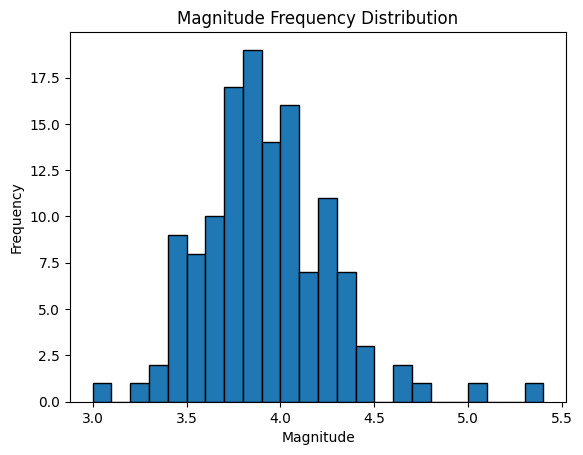

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.arange( mags.min(), mags.max(), 0.1)
plt.hist(mags,bins=bins,edgecolor='black')

plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.title("Magnitude Frequency Distribution")
plt.show()

In [ ]:
hist, edges = np.histogram(mags,bins=bins)
Mc = edges[np.argmax(hist)]

print("Mc =", round(Mc,2))

Mc = 3.8


**(b)GFT Method**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Mc_maxc = Mc
bin_width = 0.1
candidate_Mc = np.arange(Mc_maxc-0.3,Mc_maxc+0.6,bin_width)
gft_results = []

for Mc_gft in candidate_Mc:

    complete = mags[mags >= Mc_gft]

    if len(complete) < 30:
        continue

     # Aki (1965) MLE b-value
    mean_mag = np.mean(complete)
    b = np.log10(np.exp(1)) / (mean_mag - (Mc_gft - bin_width/2))

    # Observed cumulative FMD
    bins = np.arange(Mc_gft,complete.max()+bin_width,bin_width)

    hist, edges = np.histogram(complete, bins=bins)
    obs_cum = np.cumsum(hist[::-1])[::-1]
    mag_bins = edges[:-1]

    # Synthetic GR curve
    N0 = obs_cum[0]
    syn_cum = N0 * 10**(-b*(mag_bins - Mc_gft))

    # Goodness of Fit
    R = 100 - (np.sum(np.abs(obs_cum - syn_cum))/ np.sum(obs_cum)) * 100

    gft_results.append([Mc, b, R])

gft_results = pd.DataFrame( gft_results, columns=["Mc","b","GFT"])

print(gft_results.head(6))

    Mc         b        GFT
0  3.8  0.730011  72.613528
1  3.8  0.823662  74.988974
2  3.8  0.933967  76.934426
3  3.8  1.011120  75.563409
4  3.8  1.052835  81.152425
5  3.8  1.125115  74.827630


In [ ]:

mc90 = gft_results.loc[
    gft_results["GFT"] >= 90,"Mc"].min()

print("GFT Mc (90%) =", mc90)

GFT Mc (90%) = nan


**(3.b)b-value estimation**

In [ ]:
complete_mags = mags[mags >= Mc]

print("Number of complete events:",len(complete_mags))

Number of complete events: 83


In [ ]:

import numpy as np
dM = 0.1
mean_mag = np.mean(complete_mags)
b = 1 / (np.log(10) * (mean_mag - Mc + dM/2))
print("b-value =", round(b,3))

b-value = 1.011


In [ ]:
# Bootstrap 95% Confidence Interval

boot_b = []

for i in range(1000):

    sample = np.random.choice(complete_mags,size=len(complete_mags),replace=True)
    mean_sample = np.mean(sample)

    b_sample = 1 / ( np.log(10) * (mean_sample - Mc + dM/2))
    boot_b.append(b_sample)

boot_b = np.array(boot_b)

ci_low = np.percentile(boot_b, 2.5)
ci_high = np.percentile(boot_b, 97.5)

print(f"b-value = {b:.3f}")
print(f"Bootstrap 95% CI: [{ci_low:.3f}, {ci_high:.3f}]")


b-value = 1.011
Bootstrap 95% CI: [0.865, 1.172]


**b-value vs cutoff magnitude**

In [ ]:
# extracting Column containing magnitudes
magnitudes = df["magnitude"].dropna()
magnitudes

,magnitude
0,3.4
1,3.6
2,4.4
3,4.4
4,4.5
...,...
126,4.7
127,3.8
128,4.1
129,3.9


In [ ]:
# Calculate b-value for every magnitude cutoff

increment = 0.1
dM=0.1

max_mag = magnitudes.max()
Mc_values = np.arange(1.0, max_mag + increment, increment)

results = []

for Mc in Mc_values:

    M = magnitudes[magnitudes >= Mc]
    if len(M) < 20:
        continue

    # Mean magnitude
    mean_mag = np.mean(M)

    # Maximum Likelihood Estimate (Aki, 1965)
    b = np.log10(np.exp(1)) / (mean_mag - Mc + dM/2)

    # Standard Error
    sigma_b = b / np.sqrt(len(M))

    results.append([Mc, len(M), b, sigma_b])

results = pd.DataFrame(results,columns=["Mc", "Number_of_events", "b_value", "Std_Error"])

print(results.head())

    Mc  Number_of_events   b_value  Std_Error
0  1.0               131  0.143144   0.012507
1  1.1               131  0.148023   0.012933
2  1.2               131  0.153246   0.013389
3  1.3               131  0.158851   0.013879
4  1.4               131  0.164882   0.014406


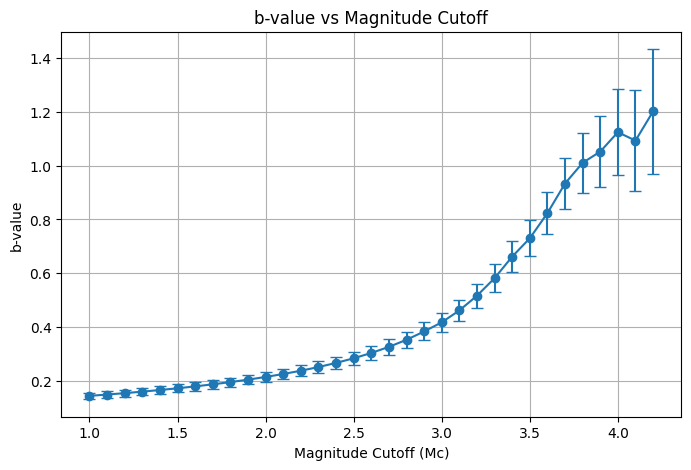

In [ ]:
plt.figure(figsize=(8,5))

plt.errorbar(results["Mc"],results["b_value"],yerr=results["Std_Error"],fmt='o-',capsize=4)

plt.xlabel("Magnitude Cutoff (Mc)")
plt.ylabel("b-value")
plt.title("b-value vs Magnitude Cutoff")
plt.grid(True)

plt.show()

In [ ]:
results.to_csv("bvalue_vs_Mc.csv", index=False)